In [98]:
import cv2
import os
import matplotlib.pyplot as plt

img_dir = '../Croptimal/resnet/train'

class_subdirs = [
    # Class 0
    # (subdir, weight)
    [('256_class_0', 1.0)],
    # Class 1
    [('256_class_1', 1.0)]]

n_classes = len(class_subdirs)
global_imgs = []

hue=[30, 50]
saturation=[110, 240]

for i, class_data in enumerate(class_subdirs):
    global_imgs.append([])
    a = True
    for subdir, weight in class_data:
        class_path = os.path.join(img_dir, subdir)
        for img_file in os.listdir(class_path):
            if img_file.endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                img_path = os.path.join(class_path, img_file)
                img = cv2.imread(img_path)
                hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
                mask = (
                    (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
                    (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
                )
                img = hsv[mask, :2]
                if img is not None:
                    global_imgs[i].append(img)

for i in range(n_classes):
    print(f'Loaded {len(global_imgs[i])} images for class {i}')

import random

dataset = []
for label in range(n_classes):
    for img in global_imgs[label]:
        dataset.append((img, label))

random.shuffle(dataset)

Loaded 2258 images for class 0
Loaded 1390 images for class 1


In [99]:
import os
import cv2
import numpy as np

def load_images_from_dir(path):
    images = []
    for fname in os.listdir(path):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            img = cv2.imread(os.path.join(path, fname))
            if img is None:
                continue
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            mask = (
                (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
                (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
            )
            img = hsv[mask, :2]
            images.append(img)
    return images

val_imgs = {
    0: load_images_from_dir("../Croptimal/resnet/val/256_class_0"),
    1: load_images_from_dir("../Croptimal/resnet/val/256_class_1"),
}

import torch

def image_to_pixels(img, samples, features=2):
    img_tensor = torch.from_numpy(img).float()

    # Normalize channels independently
    img_tensor[..., 0] /= 180.0  # Hue
    img_tensor[..., 1] /= 255.0  # Saturation

    img_flat = img_tensor.reshape(-1, features)

    if samples < img_flat.shape[0]:
        idx = torch.randperm(img_flat.shape[0])[:samples]
        img_flat = img_flat[idx]

    return img_flat


def predict_image(model, img, samples=2048):
    pixels = image_to_pixels(img, samples)

    with torch.no_grad():
        preds = model.inference(pixels)

    return torch.mode(preds).values.item()

def evaluate(model, val_imgs, samples=2048):
    TP = FP = TN = FN = 0

    for true_label, imgs in val_imgs.items():
        for img in imgs:
            pred = predict_image(model, img, samples)

            if true_label == 1:
                if pred == 1:
                    TP += 1
                else:
                    FN += 1
            else:  # true_label == 0
                if pred == 1:
                    FP += 1
                else:
                    TN += 1

    accuracy = (TP + TN) / max(TP + TN + FP + FN, 1)
    fpr = FP / max(FP + TN, 1)
    fnr = FN / max(FN + TP, 1)

    return {
        "accuracy": accuracy,
        "false_positive_rate": fpr,
        "false_negative_rate": fnr,
        "TP": TP,
        "FP": FP,
        "TN": TN,
        "FN": FN,
    }

100%|██████████| 3648/3648 [00:44<00:00, 82.82it/s] 


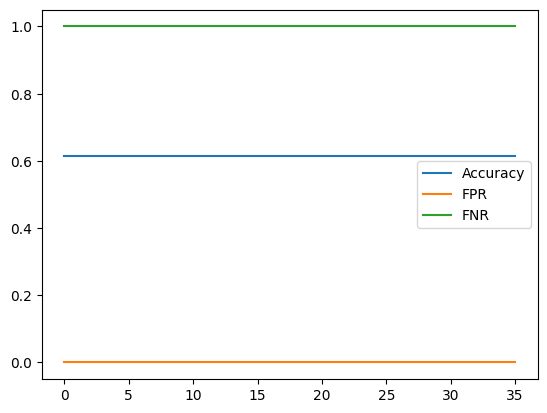

In [100]:
import sys

from tqdm import tqdm
import matplotlib.pyplot as plt
sys.path.insert(0, 'leaves-2025-07-03')
from gmlvq import gmlvq
import torch

lvq = gmlvq()
features = 2 # HSV channels (Hue and Saturation)
prototypes_per_class = 1
prototype_labels = [0, 1] * prototypes_per_class
hue_n = [hue[0] / 180.0, hue[1] / 180.0]
sat_n = [saturation[0] / 255.0, saturation[1] / 255.0]

prototypes = torch.empty(prototypes_per_class * n_classes, 2)
prototypes[:, 0].uniform_(hue_n[0], hue_n[1])
prototypes[:, 1].uniform_(sat_n[0], sat_n[1])

mu = torch.randn(features)
std = torch.randn(features) + 0.1
lvq.initialize(features, prototypes, prototype_labels, True, mu, std)

def trainImage(img, model, samples, label):
    img_tensor = torch.from_numpy(img).float()
    img_tensor[..., 0] /= 180.0  # Hue
    img_tensor[..., 1] /= 255.0  # Saturation
    img_flat = img_tensor.reshape(-1, features)

    if samples < img_flat.shape[0]:
        indices = torch.randperm(img_flat.shape[0])[:samples]
        sampled_pixels = img_flat[indices]
    else:
        samples = img_flat.shape[0]
        sampled_pixels = img_flat

    labels = torch.full((samples,), label, dtype=torch.long)

    loss = model.train(sampled_pixels, labels)
    return (loss, model.net.protos)


samples = 5000000000
# n_minibatches = 250
losses = []
accuracies = []
prototype_locations = []
# lvq.freeze_metric()
for i, (img, label) in enumerate(tqdm(dataset)):
    # if i == 50:
    #     lvq.unfreeze_metric()
    t = trainImage(img, lvq, samples, label)
    losses.append(t[0].data)
    # print(t[1].data[0], t[1].data[1])
    prototype_locations.append(t[1].data.clone().detach())
    if i % 100 == 0 and i > 0:
        accuracies.append(evaluate(lvq, val_imgs, samples=2048))

# plt.plot(losses)
plt.plot([acc['accuracy'] for acc in accuracies], label='Accuracy')
plt.plot([acc['false_positive_rate'] for acc in accuracies], label='FPR')
plt.plot([acc['false_negative_rate'] for acc in accuracies], label='FNR')
plt.legend()
plt.show()
# plt.ylim(0,1)


3648


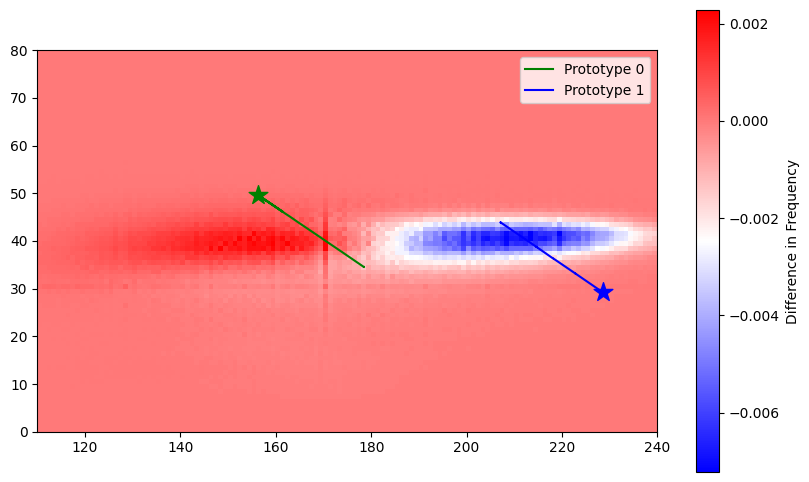

In [101]:
hue=[0, 80]
saturation=[110, 240]

print(prototype_locations.__len__())
# hist = cv2.imread('../difference_histogram.png', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(10, 6))
hist = np.load('../histogram_diff.npy')
plt.imshow(hist[hue[0]:hue[1], saturation[0]:saturation[1]], cmap='bwr', interpolation='nearest', extent=[saturation[0], saturation[1], hue[1], hue[0]])
plt.colorbar(label='Difference in Frequency')
xs0 = [proto[0][0].item()*180 for proto in prototype_locations]
ys0 = [proto[0][1].item()*255 for proto in prototype_locations]
plt.plot(ys0, xs0, label='Prototype 0', c='green')
plt.scatter(ys0[-1], xs0[-1], marker='*', s=200, c='green')
xs1 = [proto[1][0].item()*180 for proto in prototype_locations]
ys1 = [proto[1][1].item()*255 for proto in prototype_locations]
plt.plot(ys1, xs1, label='Prototype 1', c='blue')
plt.scatter(ys1[-1], xs1[-1], marker='*', s=200, c='blue')
plt.xlim(saturation[0],saturation[1])
plt.ylim(hue[0],hue[1])
plt.legend()
# plt.show()

# plt.plot([(proto[0][0].item(), proto[0][1].item()) for proto in prototype_locations], label='Prototype 0')
# plt.plot([proto[1] for proto in prototype_locations], label='Prototype 1')
# plt.legend()
# plt.show()